For this week, include ideas such as gradient boost, learning rate, number of estimators, tree depth, and regularization. This homework should be submitted for peer review in the assignment titled 9.3 Peer Review: Week 9 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [33]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import average_precision_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [34]:
random_state = 42

## Credit Card

### Import Dataset

In [35]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Undersampling due to heavy class imbalance

In [36]:
from collections import Counter


X = df.drop(columns='Class')
y = df['Class']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 284315, 1: 492})
Resampled dataset shape: Counter({0: 4920, 1: 492})


### Split Data

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Scaling

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boosting

In [39]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


We can see by default the model trained with:

learning_rate 	0.1

n_estimators 	100

max_depth 	3

In [40]:
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90       985
           1       0.35      0.91      0.50        98

    accuracy                           0.84      1083
   macro avg       0.67      0.87      0.70      1083
weighted avg       0.93      0.84      0.87      1083



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


### Plot Learning Rate

C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\19630482

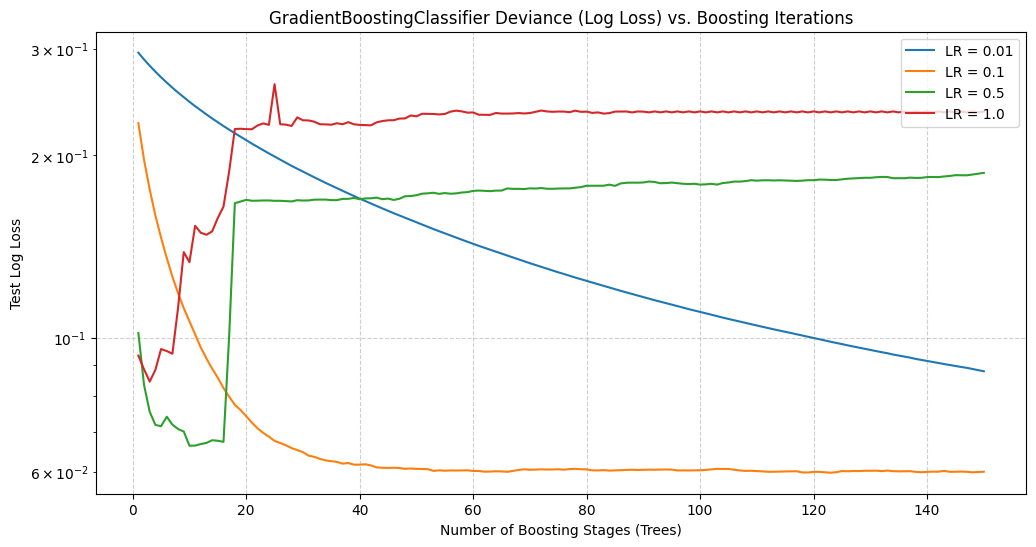

In [41]:
from sklearn.metrics import log_loss

# 2. Define the learning rates we want to evaluate
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 150

# Setup the matplotlib figure layout
plt.figure(figsize=(12, 6))

# 3. Train models and compute staged performance
for lr in learning_rates:
    # Initialize and fit the Gradient Boosting Classifier
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators, 
        learning_rate=lr, 
        max_depth=3, 
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    
    # Pre-allocate arrays for test loss
    test_loss = np.zeros((n_estimators,), dtype=np.float64)
    
    # staged_decision_function yields predictions at each boosting stage (tree)
    for i, y_pred_raw in enumerate(clf.staged_decision_function(X_test_scaled)):
        # Transform raw decision scores into probabilities via the sigmoid function
        y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
        test_loss[i] = log_loss(y_test, y_prob)
        
    # Plot the test loss trajectory for the current learning rate
    plt.plot(np.arange(n_estimators) + 1, test_loss, label=f'LR = {lr}')

# 4. Finalize plot aesthetics
plt.title('GradientBoostingClassifier Deviance (Log Loss) vs. Boosting Iterations')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Test Log Loss')
plt.yscale('log')  # Uses a log scale to better spot performance gaps
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
None

### Parameter Tuning

In [42]:
from sklearn.model_selection import StratifiedKFold

# cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
cv = StratifiedKFold(n_splits=5) # Using stratified to maintain class distribution

In [43]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-07-08 13:26:20,202] A new study created in memory with name: no-name-8f7ecd5d-6125-4e77-8937-85dac5b81265
[I 2026-07-08 13:26:25,553] Trial 0 finished with value: 0.8475170399221031 and parameters: {'n_estimators': 71, 'max_depth': 6}. Best is trial 0 with value: 0.8475170399221031.
[I 2026-07-08 13:26:30,903] Trial 1 finished with value: 0.8449853943524829 and parameters: {'n_estimators': 97, 'max_depth': 5}. Best is trial 0 with value: 0.8475170399221031.
[I 2026-07-08 13:26:46,201] Trial 2 finished with value: 0.8526777020447905 and parameters: {'n_estimators': 240, 'max_depth': 7}. Best is trial 2 with value: 0.8526777020447905.
[I 2026-07-08 13:27:02,920] Trial 3 finished with value: 0.8526777020447905 and parameters: {'n_estimators': 264, 'max_depth': 7}. Best is trial 2 with value: 0.8526777020447905.
[I 2026-07-08 13:27:10,219] Trial 4 finished with value: 0.8450178513469652 and parameters: {'n_estimators': 172, 'max_depth': 5}. Best is trial 2 with value: 0.85267770204

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
3,3,0.852678,2026-07-08 13:26:46.201178,2026-07-08 13:27:02.920367,0 days 00:00:16.719189,7,264,COMPLETE
2,2,0.852678,2026-07-08 13:26:30.903445,2026-07-08 13:26:46.201178,0 days 00:00:15.297733,7,240,COMPLETE
32,32,0.852678,2026-07-08 13:31:36.238123,2026-07-08 13:31:52.596403,0 days 00:00:16.358280,7,276,COMPLETE
31,31,0.852678,2026-07-08 13:31:23.055183,2026-07-08 13:31:36.238123,0 days 00:00:13.182940,7,224,COMPLETE
25,25,0.852678,2026-07-08 13:30:08.124431,2026-07-08 13:30:21.031246,0 days 00:00:12.906815,7,217,COMPLETE


In [44]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    n_estimators=top_5_recall_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       985
           1       0.97      0.87      0.91        98

    accuracy                           0.99      1083
   macro avg       0.98      0.93      0.95      1083
weighted avg       0.99      0.99      0.98      1083



In [45]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8497819865795726

## IBM

### Import Dataset

In [46]:
df = pd.read_csv('ibm_hi_small_trans_cleaned_semester3.csv')
df

,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,...,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,0,3697.340000,3697.340000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,0,0.010000,0.010000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,0,14675.570000,14675.570000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,0,2806.970000,2806.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,0,36682.970000,36682.970000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,0,3107.386389,3107.386389,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,0,2168.020464,2168.020464,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,0,100.011894,100.011894,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,0,770.280058,770.280058,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


### Undersampling due to heavy class imbalance

In [47]:
from collections import Counter


X = df.drop(columns='Is Laundering')
y = df['Is Laundering']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 51770, 1: 5177})


### Split Data

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Scaling

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boosting

In [50]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [51]:
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.63      0.77     10355
           1       0.20      0.90      0.32      1035

    accuracy                           0.66     11390
   macro avg       0.59      0.77      0.55     11390
weighted avg       0.91      0.66      0.73     11390



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


### Plot Learning Rate

C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\19630482

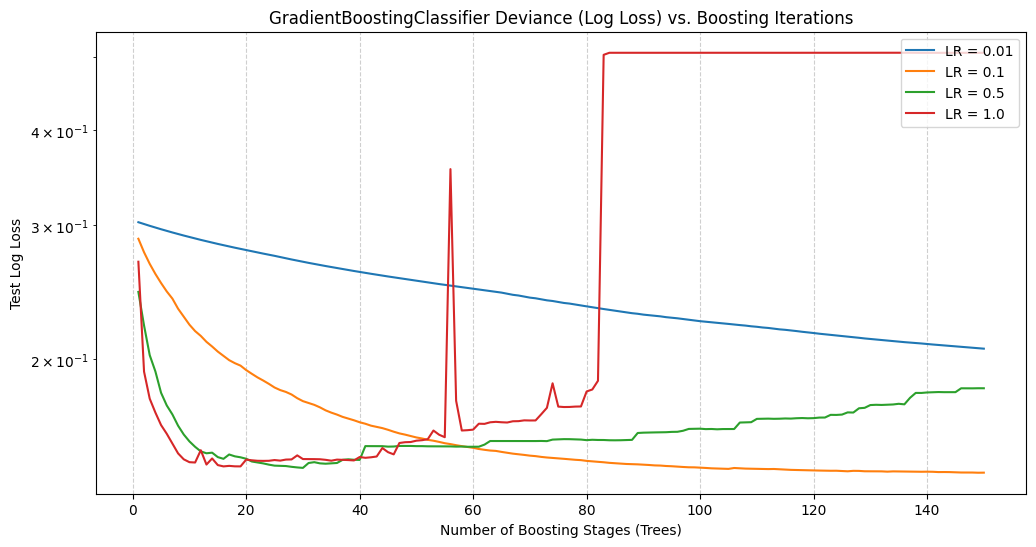

In [52]:
from sklearn.metrics import log_loss

# 2. Define the learning rates we want to evaluate
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 150

# Setup the matplotlib figure layout
plt.figure(figsize=(12, 6))

# 3. Train models and compute staged performance
for lr in learning_rates:
    # Initialize and fit the Gradient Boosting Classifier
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators, 
        learning_rate=lr, 
        max_depth=3, 
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    
    # Pre-allocate arrays for test loss
    test_loss = np.zeros((n_estimators,), dtype=np.float64)
    
    # staged_decision_function yields predictions at each boosting stage (tree)
    for i, y_pred_raw in enumerate(clf.staged_decision_function(X_test_scaled)):
        # Transform raw decision scores into probabilities via the sigmoid function
        y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
        test_loss[i] = log_loss(y_test, y_prob)
        
    # Plot the test loss trajectory for the current learning rate
    plt.plot(np.arange(n_estimators) + 1, test_loss, label=f'LR = {lr}')

# 4. Finalize plot aesthetics
plt.title('GradientBoostingClassifier Deviance (Log Loss) vs. Boosting Iterations')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Test Log Loss')
plt.yscale('log')  # Uses a log scale to better spot performance gaps
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
None

### Parameter Tuning

In [53]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-07-08 13:48:26,981] A new study created in memory with name: no-name-b44f0840-850c-4194-9853-29c58ce1e19c
[I 2026-07-08 13:48:39,339] Trial 0 finished with value: 0.6332759334044277 and parameters: {'n_estimators': 207, 'max_depth': 4}. Best is trial 0 with value: 0.6332759334044277.
[I 2026-07-08 13:48:56,323] Trial 1 finished with value: 0.6335189361491349 and parameters: {'n_estimators': 296, 'max_depth': 4}. Best is trial 1 with value: 0.6335189361491349.
[I 2026-07-08 13:49:17,036] Trial 2 finished with value: 0.6016552740919447 and parameters: {'n_estimators': 186, 'max_depth': 8}. Best is trial 1 with value: 0.6335189361491349.
[I 2026-07-08 13:49:19,230] Trial 3 finished with value: 0.580408267920724 and parameters: {'n_estimators': 33, 'max_depth': 4}. Best is trial 1 with value: 0.6335189361491349.
[I 2026-07-08 13:49:25,741] Trial 4 finished with value: 0.6200043122789228 and parameters: {'n_estimators': 64, 'max_depth': 7}. Best is trial 1 with value: 0.633518936149

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
85,85,0.642936,2026-07-08 14:02:07.682455,2026-07-08 14:02:13.126305,0 days 00:00:05.443850,3,133,COMPLETE
93,93,0.642936,2026-07-08 14:02:55.899109,2026-07-08 14:03:02.409043,0 days 00:00:06.509934,3,133,COMPLETE
94,94,0.642936,2026-07-08 14:03:02.409043,2026-07-08 14:03:08.964594,0 days 00:00:06.555551,3,133,COMPLETE
72,72,0.642694,2026-07-08 14:00:49.600740,2026-07-08 14:00:56.446376,0 days 00:00:06.845636,3,137,COMPLETE
46,46,0.642212,2026-07-08 13:57:47.845170,2026-07-08 13:57:54.793033,0 days 00:00:06.947863,3,139,COMPLETE


In [54]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    n_estimators=top_5_recall_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     10355
           1       0.74      0.65      0.69      1035

    accuracy                           0.95     11390
   macro avg       0.85      0.82      0.83     11390
weighted avg       0.95      0.95      0.95     11390



In [55]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.515644649577824

## PPP

### Import Dataset

In [56]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


### Undersampling due to heavy class imbalance

In [57]:
from collections import Counter


X = df.drop(columns='Fraud')
y = df['Fraud']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=random_state)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 968437, 1: 95})
Resampled dataset shape: Counter({0: 950, 1: 95})


### Split Data

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Scaling

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Boosting

In [60]:
model = GradientBoostingClassifier(random_state=random_state)
model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [61]:
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.57      0.11      0.19       190
           1       0.02      0.16      0.03        19

    accuracy                           0.11       209
   macro avg       0.29      0.13      0.11       209
weighted avg       0.52      0.11      0.17       209



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


### Plot Learning Rate

C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\1963048279.py:27: RuntimeWarning: overflow encountered in exp
  y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
C:\Users\caleb\AppData\Local\Temp\ipykernel_26736\19630482

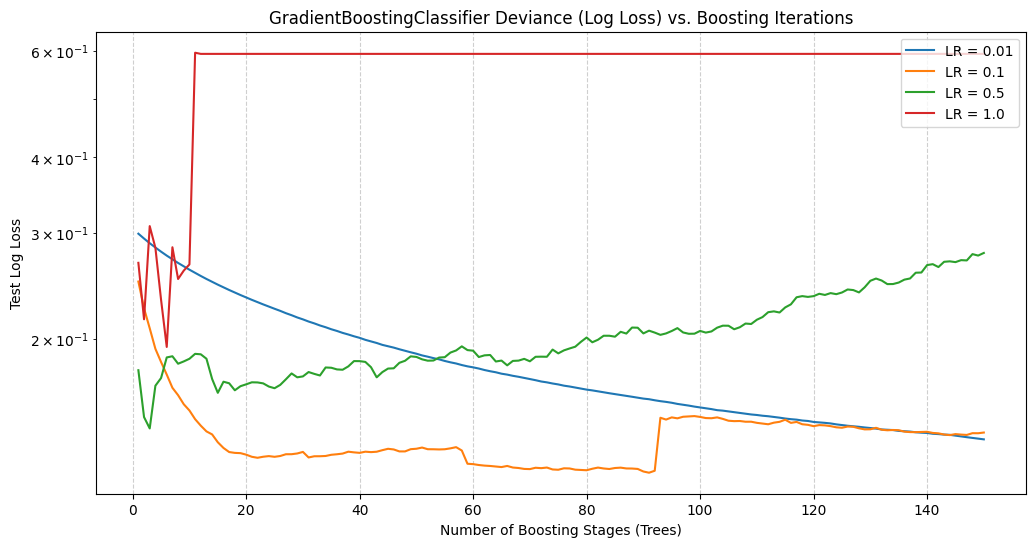

In [62]:
from sklearn.metrics import log_loss

# 2. Define the learning rates we want to evaluate
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators = 150

# Setup the matplotlib figure layout
plt.figure(figsize=(12, 6))

# 3. Train models and compute staged performance
for lr in learning_rates:
    # Initialize and fit the Gradient Boosting Classifier
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators, 
        learning_rate=lr, 
        max_depth=3, 
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    
    # Pre-allocate arrays for test loss
    test_loss = np.zeros((n_estimators,), dtype=np.float64)
    
    # staged_decision_function yields predictions at each boosting stage (tree)
    for i, y_pred_raw in enumerate(clf.staged_decision_function(X_test_scaled)):
        # Transform raw decision scores into probabilities via the sigmoid function
        y_prob = 1.0 / (1.0 + np.exp(-y_pred_raw))
        test_loss[i] = log_loss(y_test, y_prob)
        
    # Plot the test loss trajectory for the current learning rate
    plt.plot(np.arange(n_estimators) + 1, test_loss, label=f'LR = {lr}')

# 4. Finalize plot aesthetics
plt.title('GradientBoostingClassifier Deviance (Log Loss) vs. Boosting Iterations')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Test Log Loss')
plt.yscale('log')  # Uses a log scale to better spot performance gaps
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
None

### Parameter Tuning

In [63]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_int("max_depth", 2, 8)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-07-08 14:03:42,852] A new study created in memory with name: no-name-1c415385-9411-4582-bca3-bbacd1287ea8
[I 2026-07-08 14:03:43,553] Trial 0 finished with value: 0.8158333333333333 and parameters: {'n_estimators': 249, 'max_depth': 3}. Best is trial 0 with value: 0.8158333333333333.
[I 2026-07-08 14:03:44,070] Trial 1 finished with value: 0.8158333333333333 and parameters: {'n_estimators': 181, 'max_depth': 3}. Best is trial 0 with value: 0.8158333333333333.
[I 2026-07-08 14:03:45,032] Trial 2 finished with value: 0.7783333333333333 and parameters: {'n_estimators': 206, 'max_depth': 7}. Best is trial 0 with value: 0.8158333333333333.
[I 2026-07-08 14:03:45,419] Trial 3 finished with value: 0.8158333333333333 and parameters: {'n_estimators': 132, 'max_depth': 3}. Best is trial 0 with value: 0.8158333333333333.
[I 2026-07-08 14:03:45,826] Trial 4 finished with value: 0.8158333333333333 and parameters: {'n_estimators': 129, 'max_depth': 3}. Best is trial 0 with value: 0.815833333

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
84,84,0.829167,2026-07-08 14:04:34.981808,2026-07-08 14:04:35.783920,0 days 00:00:00.802112,3,289,COMPLETE
70,70,0.829167,2026-07-08 14:04:23.801364,2026-07-08 14:04:24.594730,0 days 00:00:00.793366,3,288,COMPLETE
73,73,0.829167,2026-07-08 14:04:26.117135,2026-07-08 14:04:26.914684,0 days 00:00:00.797549,3,291,COMPLETE
82,82,0.829167,2026-07-08 14:04:33.317961,2026-07-08 14:04:34.149588,0 days 00:00:00.831627,3,291,COMPLETE
69,69,0.829167,2026-07-08 14:04:22.999352,2026-07-08 14:04:23.800363,0 days 00:00:00.801011,3,287,COMPLETE


In [64]:
# Train using optimal parameters
model = GradientBoostingClassifier(
    n_estimators=top_5_recall_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    random_state=random_state
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       190
           1       0.79      0.79      0.79        19

    accuracy                           0.96       209
   macro avg       0.88      0.88      0.88       209
weighted avg       0.96      0.96      0.96       209



In [65]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.6424074540418031

## Conclusions

We can see in the plots that the default learning rate (0.01) performed the best across the datasets after boosting stages. The larger rates performed best for the beginning stages of boosting, but then are surpassed by the slower learning rate 

In terms of parameter tuning, 